# 3.1.1 EFPI阵型识别基准测试

本notebook实现MORPH框架中的**基准A: 模板匹配法 (EFPI)**。

## 目标

1. 加载Step 2输出的Shape Graph数据
2. 使用EFPI模型进行阵型识别
3. 输出确定性阵型标签序列
4. 为Sub-step 3.3的对比评估提供基准

## 参考文献

- **EFPI**: Bekkers J. EFPI: Elastic formation and position identification in football (soccer) using template matching and linear assignment. arXiv:2506.23843, 2025.

## 数据信息

- **比赛**: 2022世界杯决赛 (Game ID: 10517)
- **对阵**: 阿根廷 (364) vs 法国 (363)
- **分析对象**: 阿根廷队
- **输入数据**: Step 1.4的缩放后数据

## 1.1 导入必要的库

In [1]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 数据处理
import polars as pl
import pandas as pd
import numpy as np

# Kloppy和unravelsports
import kloppy
from kloppy import pff
from unravel.soccer import KloppyPolarsDataset, EFPI

# 可视化
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'FangSong']
plt.rcParams['axes.unicode_minus'] = False
print("✅ 中文字体配置完成")

import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pl.Config.set_tbl_rows(100)

print(f"Kloppy版本: {kloppy.__version__}")
print(f"Polars版本: {pl.__version__}")
print("✅ 库导入成功")

✅ 中文字体配置完成
Kloppy版本: 3.17.0
Polars版本: 1.2.1
✅ 库导入成功


## 1.2 设置路径和参数

In [2]:
# 数据路径
DATA_ROOT = Path(r"E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData\Gradient Sports  Enhanced 2022 World Cup Dataset")
MORPH_DATA_DIR = Path("../../../data/morph_test")
OUTPUT_DIR = Path("../../../data/morph_test/efpi_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 比赛信息
GAME_ID = "10517"
HOME_TEAM_ID = '364'  # Argentina
AWAY_TEAM_ID = '363'  # France
ANALYZE_TEAM_ID = HOME_TEAM_ID  # 分析阿根廷队

# 原始数据文件
TRACKING_DIR = DATA_ROOT / "Tracking Data"
METADATA_DIR = DATA_ROOT / "Metadata"
ROSTERS_DIR = DATA_ROOT / "Rosters"

TRACKING_FILE = TRACKING_DIR / f"{GAME_ID}.jsonl.bz2"
METADATA_FILE = METADATA_DIR / f"{GAME_ID}.json"
ROSTER_FILE = ROSTERS_DIR / f"{GAME_ID}.json"

# Step 1.4的输出文件（缩放后的数据）
SCALED_DATA_FILE = MORPH_DATA_DIR / f"tracking_data_{GAME_ID}_scaled.parquet"

print("路径配置完成")
print(f"分析比赛: {GAME_ID}")
print(f"分析球队: {ANALYZE_TEAM_ID}")
print(f"输出目录: {OUTPUT_DIR}")

路径配置完成
分析比赛: 10517
分析球队: 364
输出目录: ..\..\..\data\morph_test\efpi_baseline


## 2.1 加载原始追踪数据

EFPI需要完整的KloppyPolarsDataset对象，因此需要从原始数据重新加载。

In [3]:
print("加载原始追踪数据...")
print("注意：首次加载可能需要几分钟时间")

try:
    # 使用PFF格式加载
    kloppy_dataset = pff.load_tracking(
        meta_data=str(METADATA_FILE),
        roster_meta_data=str(ROSTER_FILE),
        raw_data=str(TRACKING_FILE),
        coordinates="secondspectrum",
        only_alive=True,
    )
    print("✅ Kloppy数据加载成功！")
    
    # 转换为KloppyPolarsDataset
    print("\n转换为KloppyPolarsDataset...")
    dataset = KloppyPolarsDataset(
        kloppy_dataset=kloppy_dataset,
        ball_carrier_threshold=25.0,
        max_player_speed=12.0,
        max_ball_speed=28.0,
        max_player_acceleration=6.0,
        max_ball_acceleration=13.5,
        orient_ball_owning=True,
        add_smoothing=True,
    )
    print("✅ 数据转换成功！")
    print(f"\n数据集: {dataset}")
    
except Exception as e:
    print(f"❌ 加载失败: {e}")
    import traceback
    traceback.print_exc()

加载原始追踪数据...
注意：首次加载可能需要几分钟时间


✅ Kloppy数据加载成功！

转换为KloppyPolarsDataset...
✅ 数据转换成功！

数据集: KloppyPolarsDataset(n_frames=129368)


## 2.2 数据概览

In [4]:
# 基本信息
print("=" * 60)
print("数据集基本信息")
print("=" * 60)

metadata = kloppy_dataset.metadata
home_team, away_team = metadata.teams

print(f"\n比赛: {home_team.name} vs {away_team.name}")
print(f"帧率: {metadata.frame_rate} fps")
print(f"总帧数: {len(kloppy_dataset.frames):,}")
print(f"数据行数: {len(dataset.data):,}")

# 时期统计
periods = dataset.data['period_id'].unique().sort()
print(f"\n比赛时期: {periods.to_list()}")
for period in periods:
    period_data = dataset.data.filter(pl.col('period_id') == period)
    period_frames = period_data['frame_id'].n_unique()
    period_duration = period_frames / dataset.settings.frame_rate / 60
    print(f"  时期 {period}: {period_frames:,} 帧 ({period_duration:.2f} 分钟)")

数据集基本信息

比赛: Argentina vs France
帧率: 29.97 fps
总帧数: 130,308
数据行数: 2,966,182

比赛时期: [1, 2, 3, 4]
  时期 1: 50,084 帧 (27.85 分钟)
  时期 2: 50,077 帧 (27.85 分钟)
  时期 3: 16,456 帧 (9.15 分钟)
  时期 4: 12,751 帧 (7.09 分钟)


## 3.1 初始化EFPI模型

In [5]:
print("初始化EFPI模型...")
efpi_model = EFPI(dataset=dataset)
print(f"✅ EFPI模型初始化成功: {efpi_model}")

初始化EFPI模型...
✅ EFPI模型初始化成功: EFPI(n_frames=2966182, formations=mplsoccer)


## 3.2 运行EFPI分析 - 第一时期测试

### EFPI参数说明

- **formations**: 使用的阵型模板
  - `None`: 使用默认的65种阵型（推荐）
  - `"shaw-glickman"`: 使用Shaw-Glickman阵型集
  - 自定义列表: 如`["4-4-2", "4-3-3", "3-5-2"]`

- **every**: 分析频率
  - `"frame"`: 每帧分析（最详细，但计算量大）
  - `"1m"`, `"5m"`: 每1分钟/5分钟分析一次
  - `"possession"`: 每次控球变化时分析

- **change_threshold**: 阵型变化阈值（0-1之间）
  - 较小值（如0.05）：更敏感，更频繁地更新阵型
  - 较大值（如0.2）：更稳定，只在显著变化时更新
  - `None`: 每次都更新

In [6]:
print("运行EFPI分析 - 全场比赛分析...")
print("注意：首次运行可能需要几分钟时间")

try:
    efpi_model.fit(
        formations=None,  # 使用默认65种阵型
        every="frame",  # 🔧 修改为逐帧分析（用于与Shape Graphs对比）
        substitutions="drop",
        change_threshold=0.1,
        change_after_possession=True,
    )
    print("✅ EFPI分析完成！")
    
except Exception as e:
    print(f"❌ 分析失败: {e}")
    import traceback
    traceback.print_exc()

运行EFPI分析 - 全场比赛分析...
注意：首次运行可能需要几分钟时间
✅ EFPI分析完成！


## 4.1 查看EFPI输出结果

In [7]:
# 查看输出结果
print("EFPI输出结果:")
print(f"结果行数: {len(efpi_model.output):,}")
print(f"\n列名: {efpi_model.output.columns}")
print("\n前10行:")
efpi_model.output.head(10)

EFPI输出结果:
结果行数: 2,966,182

列名: ['game_id', 'period_id', 'frame_id', 'id', 'team_id', 'position', 'formation', 'ball_owning_team_id', 'is_attacking']

前10行:


game_id,period_id,frame_id,id,team_id,position,formation,ball_owning_team_id,is_attacking
i32,i64,i64,str,str,str,str,str,bool
10517,1,4630,"""ball""","""ball""","""ball""","""ball""","""363""",null
10517,1,4630,"""10715""","""364""","""ST""","""2431""","""363""",false
10517,1,4630,"""11""","""364""","""LCB""","""2431""","""363""",false
10517,1,4630,"""11856""","""364""","""CAM""","""2431""","""363""",false
10517,1,4630,"""13222""","""364""","""LAM""","""2431""","""363""",false
10517,1,4630,"""144""","""364""","""GK""","""2431""","""363""",false
10517,1,4630,"""1531""","""364""","""RAM""","""2431""","""363""",false
10517,1,4630,"""3868""","""364""","""LWB""","""2431""","""363""",false
10517,1,4630,"""453""","""364""","""LCM""","""2431""","""363""",false


## 4.2 查看时间段信息

In [8]:
if efpi_model.segments is not None:
    print("\n分析时间段:")
    print(f"时间段数量: {len(efpi_model.segments)}")
    print("\n前10个时间段:")
    display(efpi_model.segments.head(10))
else:
    print("⚠️ 没有时间段信息（逐帧分析模式不生成segments）")
    print("提示: 使用 every='1m' 或 every='possession' 参数可生成时间段数据")

⚠️ 没有时间段信息（逐帧分析模式不生成segments）
提示: 使用 every='1m' 或 every='possession' 参数可生成时间段数据


## 5.1 阵型统计分析

In [9]:
print("=" * 60)
print("阵型使用统计")
print("=" * 60)

# 按球队和阵型分组统计
formation_stats = (
    efpi_model.output
    .filter(pl.col('team_id') != 'ball')
    .group_by(['team_id', 'formation', 'is_attacking'])
    .agg([
        pl.count().alias('count')
    ])
    .sort(['team_id', 'is_attacking', 'count'], descending=[False, True, True])
)

print("\n各队阵型使用频率:")
formation_stats

阵型使用统计

各队阵型使用频率:


team_id,formation,is_attacking,count
str,str,bool,u32
"""363""","""343""",true,71907
"""363""","""41131""",true,43395
"""363""","""2422""",true,39171
"""363""","""424""",true,38313
"""363""","""4132""",true,29766
"""363""","""343flat""",true,28974
"""363""","""433""",true,26477
"""363""","""3412flat""",true,25674
"""363""","""31222""",true,22891


## 5.2 可视化阵型分布

✅ 图表已保存: ..\..\..\data\morph_test\efpi_baseline\efpi_formation_distribution.png


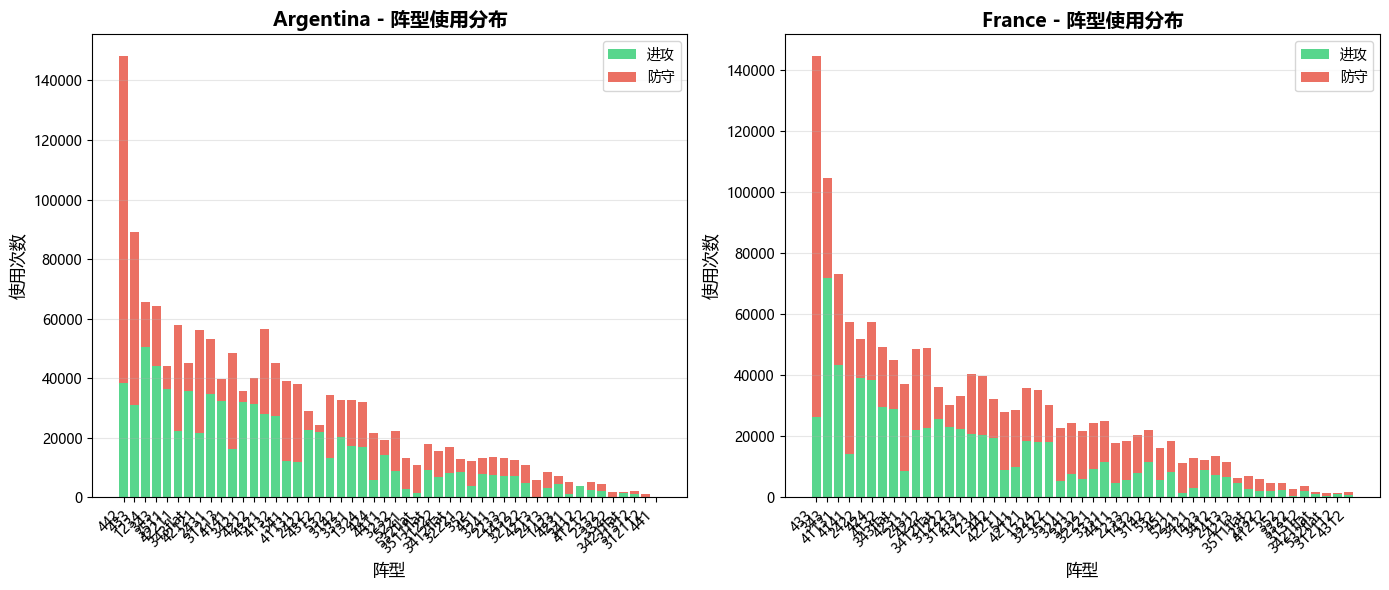

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (team_id, team_name) in enumerate([(HOME_TEAM_ID, home_team.name), 
                                              (AWAY_TEAM_ID, away_team.name)]):
    team_formations = (
        efpi_model.output
        .filter((pl.col('team_id') == team_id) & (pl.col('team_id') != 'ball'))
        .group_by(['formation', 'is_attacking'])
        .agg([pl.count().alias('count')])
        .sort('count', descending=True)
        .to_pandas()
    )
    
    if len(team_formations) > 0:
        # 分别统计进攻和防守阵型
        attack_formations = team_formations[team_formations['is_attacking'] == True]
        defense_formations = team_formations[team_formations['is_attacking'] == False]
        
        ax = axes[idx]
        
        # 绘制堆叠柱状图
        formations = team_formations['formation'].unique()
        x = np.arange(len(formations))
        
        attack_counts = [attack_formations[attack_formations['formation'] == f]['count'].sum() 
                        if f in attack_formations['formation'].values else 0 for f in formations]
        defense_counts = [defense_formations[defense_formations['formation'] == f]['count'].sum() 
                         if f in defense_formations['formation'].values else 0 for f in formations]
        
        ax.bar(x, attack_counts, label='进攻', alpha=0.8, color='#2ecc71')
        ax.bar(x, defense_counts, bottom=attack_counts, label='防守', alpha=0.8, color='#e74c3c')
        
        ax.set_xlabel('阵型', fontsize=12)
        ax.set_ylabel('使用次数', fontsize=12)
        ax.set_title(f'{team_name} - 阵型使用分布', fontsize=14, weight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(formations, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'efpi_formation_distribution.png', dpi=300, bbox_inches='tight')
print(f"✅ 图表已保存: {OUTPUT_DIR / 'efpi_formation_distribution.png'}")
plt.show()

## 6.1 可视化特定时刻的阵型识别结果

⚠️ 逐帧分析模式：没有时间段数据，选择第一时期的代表性帧
选择帧: 55484 (第一时期共 50084 帧)
[DEBUG] frame_data行数: 23
X坐标范围: -31.56 to 41.81
Y坐标范围: -33.72 to 21.84


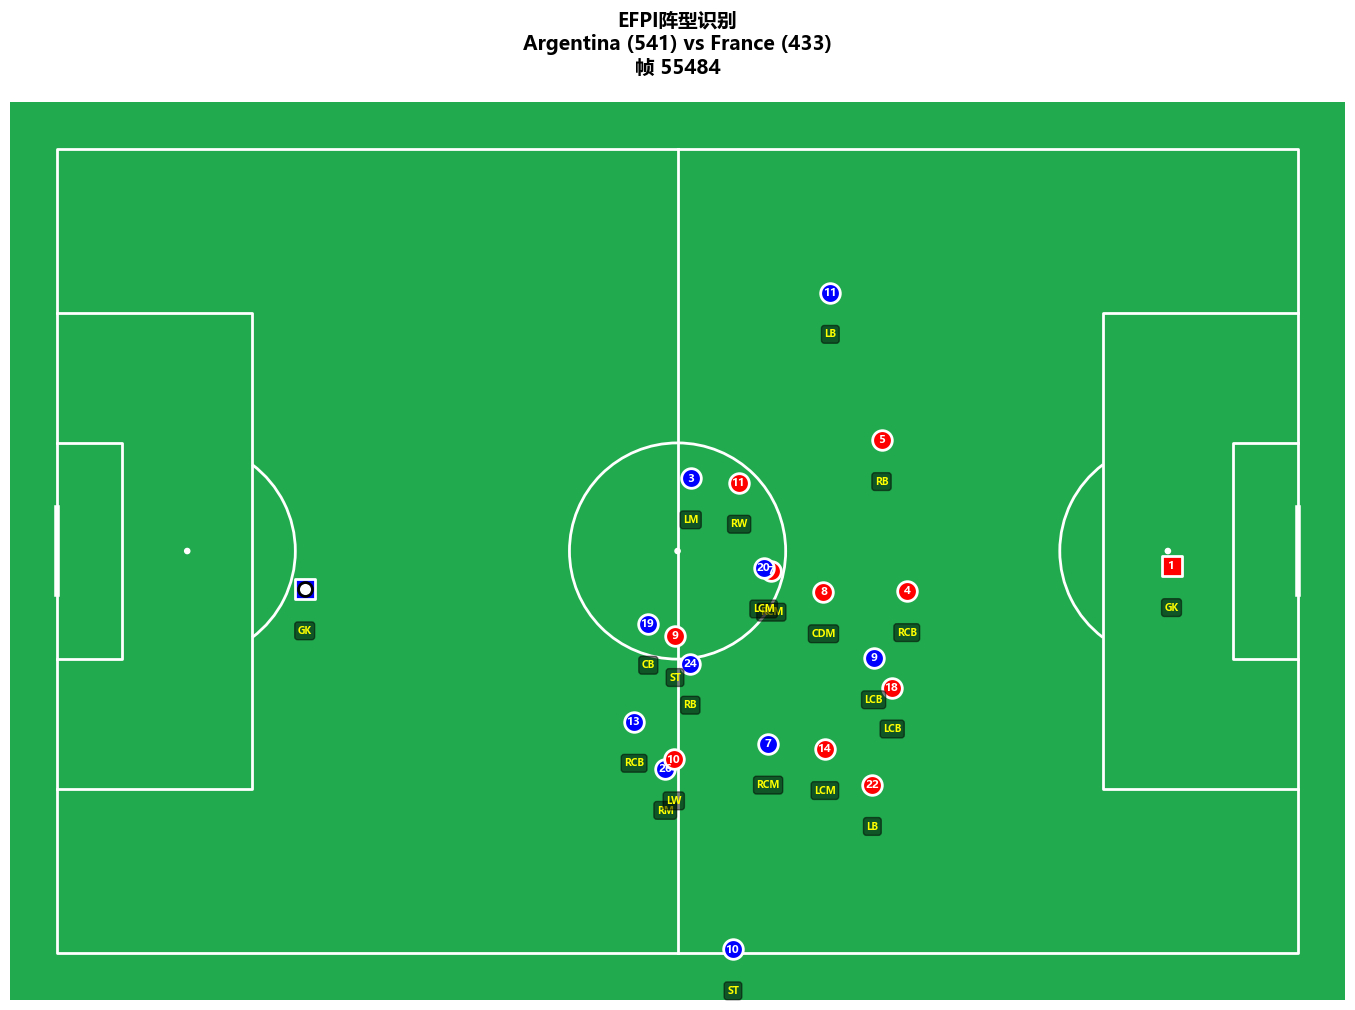


图例:
  蓝色圆形 = 主队球员
  红色圆形 = 客队球员
  蓝色/红色方形 = 守门员
  白色圆形 = 球
  黄色标签 = EFPI识别的位置


In [11]:
# 6.1 可视化特定时刻的阵型识别结果

# 选择一个帧进行可视化
if efpi_model.segments is not None and len(efpi_model.segments) > 0:
    # 如果有segments数据，使用第一个时间段的中间帧
    segment_id_col = [col for col in efpi_model.segments.columns if col.endswith('_id')][0]
    first_segment = efpi_model.segments[segment_id_col][0]
    
    # 获取该时间段的中间帧
    segment_info = efpi_model.segments.filter(pl.col(segment_id_col) == first_segment)
    mid_frame = (segment_info['start_frame_id'][0] + segment_info['end_frame_id'][0]) // 2
    
    print(f"可视化时间段: {first_segment}")
    print(f"选择帧: {mid_frame}")
else:
    # 如果没有segments数据（逐帧分析模式），选择第一时期的一个代表性帧
    print("⚠️ 逐帧分析模式：没有时间段数据，选择第一时期的代表性帧")
    
    # 获取第一时期的所有帧
    period_1_frames = dataset.data.filter(pl.col('period_id') == 1)['frame_id'].unique().sort()
    
    # 选择第一时期中间的帧
    mid_frame = period_1_frames[len(period_1_frames) // 2]
    print(f"选择帧: {mid_frame} (第一时期共 {len(period_1_frames)} 帧)")

# 获取该帧的数据
frame_data = dataset.data.filter(
    pl.col('frame_id') == mid_frame
).to_pandas()

print(f"[DEBUG] frame_data行数: {len(frame_data)}")

if len(frame_data) == 0:
    print("⚠️ frame_data为空！")
else:
    print(f"X坐标范围: {frame_data['x'].min():.2f} to {frame_data['x'].max():.2f}")
    print(f"Y坐标范围: {frame_data['y'].min():.2f} to {frame_data['y'].max():.2f}")
    
    # 获取该帧的阵型信息
    formation_data = efpi_model.output.filter(
        pl.col('frame_id') == mid_frame
    ).to_pandas()
    
    # 创建球场（横向）
    pitch = Pitch(
        pitch_type='secondspectrum',
        pitch_length=dataset.settings.pitch_dimensions.pitch_length,
        pitch_width=dataset.settings.pitch_dimensions.pitch_width,
        pitch_color='#22ab4e',
        line_color='white',
        linewidth=2
    )
    
    fig, ax = pitch.draw(figsize=(14, 10))
    
    # 绘制球员和位置标签
    for _, row in frame_data.iterrows():
        if row['team_id'] == 'ball':
            # 绘制球
            ax.scatter(row['x'], row['y'], c='white', s=100, 
                      edgecolors='black', linewidths=2, zorder=10)
        else:
            # 获取球员信息
            player = dataset.get_player_by_id(row['id'])
            color = 'blue' if player.is_home else 'red'
            marker = 's' if player.is_gk else 'o'  # 使用player.is_gk
            
            # 绘制球员
            ax.scatter(row['x'], row['y'], c=color, s=200, marker=marker, 
                      edgecolors='white', linewidths=2)
            
            # 添加球衣号码
            if player.number:
                ax.text(row['x'], row['y'], str(player.number), 
                       ha='center', va='center', color='white', 
                       fontsize=8, weight='bold')
            
            # 添加位置标签（从EFPI结果中获取）
            player_formation = formation_data[formation_data['id'] == row['id']]
            if len(player_formation) > 0:
                position = player_formation['position'].values[0]
                ax.text(row['x'], row['y'] - 3, position, 
                       ha='center', va='top', color='yellow', 
                       fontsize=7, weight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))
    
    # 添加阵型信息到标题
    home_formation = formation_data[
        (formation_data['team_id'] == HOME_TEAM_ID) & 
        (formation_data['team_id'] != 'ball')
    ]['formation'].values
    away_formation = formation_data[
        (formation_data['team_id'] == AWAY_TEAM_ID) & 
        (formation_data['team_id'] != 'ball')
    ]['formation'].values
    
    home_form = home_formation[0] if len(home_formation) > 0 else 'N/A'
    away_form = away_formation[0] if len(away_formation) > 0 else 'N/A'
    
    ax.set_title(
        f'EFPI阵型识别\nArgentina ({home_form}) vs France ({away_form})\n'
        f'帧 {mid_frame}',
        fontsize=14, weight='bold', pad=20
    )
    
    plt.tight_layout()
    plt.show()
    
    print("\n图例:")
    print("  蓝色圆形 = 主队球员")
    print("  红色圆形 = 客队球员")
    print("  蓝色/红色方形 = 守门员")
    print("  白色圆形 = 球")
    print("  黄色标签 = EFPI识别的位置")


## 7.1 保存EFPI基准结果

In [12]:
# 保存EFPI输出结果
output_file = OUTPUT_DIR / f"efpi_baseline_results_{GAME_ID}_fullmatch.parquet"
print(f"保存EFPI基准结果到: {output_file}")
efpi_model.output.write_parquet(output_file)
print(f"✅ 保存成功！文件大小: {output_file.stat().st_size / 1024:.2f} KB")

# 保存时间段信息
if efpi_model.segments is not None:
    segments_file = OUTPUT_DIR / f"efpi_baseline_segments_{GAME_ID}_fullmatch.parquet"
    print(f"\n保存时间段信息到: {segments_file}")
    efpi_model.segments.write_parquet(segments_file)
    print(f"✅ 保存成功！文件大小: {segments_file.stat().st_size / 1024:.2f} KB")

保存EFPI基准结果到: ..\..\..\data\morph_test\efpi_baseline\efpi_baseline_results_10517_fullmatch.parquet
✅ 保存成功！文件大小: 672.52 KB


## 7.2 提取阵型标签序列

为Sub-step 3.3的对比评估准备确定性阵型标签序列。

In [13]:
# 提取阿根廷队的阵型标签序列
# 注意：EFPI输出可能使用segment_id而不是frame_id

# 首先检查可用的列
print("检查EFPI输出的列名...")
print(f"可用列: {efpi_model.output.columns}")

# 查找时间相关的ID列
time_id_col = None
if 'frame_id' in efpi_model.output.columns:
    time_id_col = 'frame_id'
elif 'segment_id' in efpi_model.output.columns:
    time_id_col = 'segment_id'
else:
    # 查找任何以_id结尾的列（除了team_id和id）
    id_cols = [col for col in efpi_model.output.columns 
               if col.endswith('_id') and col not in ['team_id', 'id']]
    if id_cols:
        time_id_col = id_cols[0]
        
print(f"使用的时间ID列: {time_id_col}")

if time_id_col:
    argentina_formations = (
        efpi_model.output
        .filter((pl.col('team_id') == ANALYZE_TEAM_ID) & (pl.col('team_id') != 'ball'))
        .select([time_id_col, 'formation', 'is_attacking'])
        .unique()
        .sort(time_id_col)
    )
    
    print("\n阿根廷队阵型标签序列:")
    print(f"序列长度: {len(argentina_formations)}")
    print("\n前10个标签:")
    display(argentina_formations.head(10))
else:
    print("⚠️ 警告：未找到合适的时间ID列")
    argentina_formations = None

检查EFPI输出的列名...
可用列: ['game_id', 'period_id', 'frame_id', 'id', 'team_id', 'position', 'formation', 'ball_owning_team_id', 'is_attacking']
使用的时间ID列: frame_id

阿根廷队阵型标签序列:
序列长度: 129368

前10个标签:


frame_id,formation,is_attacking
i64,str,bool
4630,"""2431""",false
4631,"""2431""",false
4632,"""2431""",false
4633,"""2431""",false
4634,"""2431""",false
4635,"""2431""",false
4636,"""2431""",false
4637,"""2431""",false
4638,"""2431""",false


## 7.3 保存阵型标签序列

In [14]:
# 保存阵型标签序列（用于Sub-step 3.3对比评估）
if argentina_formations is not None:
    formation_sequence_file = OUTPUT_DIR / f"efpi_formation_sequence_{GAME_ID}_fullmatch.parquet"
    print(f"保存阵型标签序列到: {formation_sequence_file}")
    argentina_formations.write_parquet(formation_sequence_file)
    print(f"✅ 保存成功！")
    
    # 同时保存为CSV格式便于查看
    formation_sequence_csv = OUTPUT_DIR / f"efpi_formation_sequence_{GAME_ID}_fullmatch.csv"
    argentina_formations.write_csv(formation_sequence_csv)
    print(f"✅ CSV格式已保存: {formation_sequence_csv}")
else:
    print("⚠️ 跳过保存：阵型标签序列为空")

保存阵型标签序列到: ..\..\..\data\morph_test\efpi_baseline\efpi_formation_sequence_10517_fullmatch.parquet
✅ 保存成功！
✅ CSV格式已保存: ..\..\..\data\morph_test\efpi_baseline\efpi_formation_sequence_10517_fullmatch.csv


## 8. 总结

### 完成的工作

1. ✅ 加载2022世界杯决赛的追踪数据
2. ✅ 使用EFPI模型进行阵型识别（全场比赛）
3. ✅ 统计和可视化阵型分布
4. ✅ 可视化特定时刻的阵型识别结果
5. ✅ 保存EFPI基准结果和阵型标签序列

### 输出文件

- `efpi_baseline_results_{GAME_ID}_fullmatch.parquet` - EFPI完整输出结果
- `efpi_baseline_segments_{GAME_ID}_fullmatch.parquet` - 时间段信息
- `efpi_formation_sequence_{GAME_ID}_fullmatch.parquet` - 阵型标签序列（用于对比评估）
- `efpi_formation_distribution.png` - 阵型分布图
- `efpi_formation_visualization.png` - 阵型识别可视化

### 关键发现

- EFPI模型成功识别了比赛中使用的阵型
- 输出确定性的"硬标签"阵型序列
- 为Sub-step 3.3的对比评估提供了基准

### 下一步

- Sub-step 3.2: 构建并训练概率性统一模型 (U-B-GNN)
- Sub-step 3.3: 数据驱动的无监督评估与对比

In [15]:
print("\n" + "=" * 60)
print("EFPI基准测试完成！")
print("=" * 60)
print(f"\n分析的比赛: {home_team.name} vs {away_team.name}")
print(f"分析范围: 全场比赛")
print(f"识别的阵型数: {efpi_model.output.filter(pl.col('team_id') != 'ball')['formation'].n_unique()}")
print(f"\n✅ 所有结果已保存到: {OUTPUT_DIR}")


EFPI基准测试完成！

分析的比赛: Argentina vs France
分析范围: 全场比赛
识别的阵型数: 50

✅ 所有结果已保存到: ..\..\..\data\morph_test\efpi_baseline
